In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from step1.MLP_model import MLP

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
X_train = np.load('preprocessing/X_train.npy')
X_val = np.load('preprocessing/X_val.npy')
X_test = np.load('preprocessing/X_test.npy')
y_train = np.load('preprocessing/y_train.npy')
y_val = np.load('preprocessing/y_val.npy')
y_test = np.load('preprocessing/y_test.npy')

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (2099, 13), Val: (450, 13), Test: (451, 13)


GA

In [3]:
from sklearn.metrics import f1_score

# gene options
NEURON_OPTIONS = [16, 32, 64, 128, 256]

ACTIVATIONS = ['relu', 'tanh', 'sigmoid']

LR_OPTIONS = [0.0005, 0.001, 0.005, 0.01]

L2_OPTIONS = [0.0, 0.0001, 0.001, 0.01]

BATCH_OPTIONS = [16, 32, 64, 128]

INIT_OPTIONS = ['random', 'xavier', 'he']


def create_random_chromosome():
    # layer1, layer2, layer3, activation, lr, l2, batch size, weight init
    number_of_layers = random.randint(1, 3)
    layers = []
    for i in range(3):
        if i < number_of_layers:
            layers.append(random.choice(NEURON_OPTIONS))
        else:
            layers.append(0)  # اگر تعداد لایه ها کمتر از 3 باشد لایه های آخر تعداد نرون 0 خواند داشت

    chromosome = [
        layers[0], layers[1], layers[2], random.choice(ACTIVATIONS), random.choice(LR_OPTIONS),
        random.choice(L2_OPTIONS), random.choice(BATCH_OPTIONS), random.choice(INIT_OPTIONS)
    ]
    return chromosome


def initialize_population(population_size):
    population = []
    for i in range(population_size):
        population.append(create_random_chromosome())

    return population


def decode_chromosome(chromosome, input_size, output_size):
    layer1, layer2, layer3, activation, lr, l2, batch_size, weight_init = chromosome

    hidden_layers = []
    for layer in [layer1, layer2, layer3]:
        if layer != 0:
            hidden_layers.append(layer)

    layer_sizes = [input_size] + hidden_layers + [output_size]

    return {
        "layer_sizes": layer_sizes,
        "activation": activation,
        "learning_rate": lr,
        "l2_lambda": l2,
        "batch_size": batch_size,
        "weight_init": weight_init
    }


def evaluate_chromosome(chromosome, input_size, output_size):
    np.random.seed(42)
    params = decode_chromosome(chromosome, input_size, output_size)
    model = MLP(layer_sizes=params["layer_sizes"],
                activation=params["activation"],
                learning_rate=params["learning_rate"],
                l2_lambda=params["l2_lambda"],
                weight_init=params["weight_init"])

    model.train(X_train, y_train, X_val, y_val, epochs=100,
                          batch_size=params["batch_size"],
                          early_stopping_patience=10,
                          verbose=False)
    y_pred, _ = model.predict(X_val)
    fitness = f1_score(y_val, y_pred, average='macro')

    return fitness


def evaluate_population(population, input_size, output_size):
    fitness_scores = []
    for chromosome in population:
        fitness = evaluate_chromosome(chromosome, input_size, output_size)
        fitness_scores.append(fitness)
    return fitness_scores


def tournament_selection(population, fitness_scores, tournament_size=3):
    selected_indices = random.sample(range(len(population)), tournament_size)
    best_idx = selected_indices[0]

    for idx in selected_indices[1:]:
        if fitness_scores[idx] > fitness_scores[best_idx]:
            best_idx = idx

    return population[best_idx].copy()


def crossover(parent1, parent2, crossover_rate=0.8):
    if random.random() > crossover_rate:
        return parent1.copy(), parent2.copy()

    child1 = parent1.copy()
    child2 = parent2.copy()

    for i in range(len(parent1)):
        if random.random() < 0.5:
            child1[i], child2[i] = child2[i], child1[i]

    return child1, child2


def mutate(chromosome, mutation_rate=0.2):
    mutated = chromosome.copy()

    if random.random() < mutation_rate:
        number_of_layers = random.randint(1, 3)
        layers = []
        for i in range(3):
            if i < number_of_layers:
                layers.append(random.choice(NEURON_OPTIONS))
            else:
                layers.append(0)
        mutated[0], mutated[1], mutated[2] = layers[0], layers[1], layers[2]

    if random.random() < mutation_rate:
        mutated[3] = random.choice(ACTIVATIONS)

    if random.random() < mutation_rate:
        mutated[4] = random.choice(LR_OPTIONS)

    if random.random() < mutation_rate:
        mutated[5] = random.choice(L2_OPTIONS)

    if random.random() < mutation_rate:
        mutated[6] = random.choice(BATCH_OPTIONS)

    if random.random() < mutation_rate:
        mutated[7] = random.choice(INIT_OPTIONS)

    return mutated


def run_genetic_algorithm(population_size=30, generations=15, crossover_rate=0.8, mutation_rate=0.2, elitism=True):
    input_size = X_train.shape[1]
    output_size = len(np.unique(y_train))

    population = initialize_population(population_size)
    best_chromosome = None
    best_fitness = -1
    history = []

    for generation in range(generations):
        print(f"\n========== Generation {generation + 1}/{generations} ==========")

        fitness_scores = evaluate_population(population, input_size, output_size)
        best_index = np.argmax(fitness_scores)
        gen_best_chromosome = population[best_index]
        gen_best_fitness = fitness_scores[best_index]
        avg_fitness = np.mean(fitness_scores)

        history.append({
            "generation": generation + 1,
            "best_fitness": gen_best_fitness,
            "avg_fitness": avg_fitness,
            "best_chromosome": gen_best_chromosome
        })

        if best_fitness < gen_best_fitness:
            best_chromosome = gen_best_chromosome
            best_fitness = gen_best_fitness

        new_population = []
        if elitism:
            new_population.append(gen_best_chromosome.copy())

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, fitness_scores)
            parent2 = tournament_selection(population, fitness_scores)

            child1, child2 = crossover(parent1, parent2, crossover_rate)
            child1 = mutate(child1, mutation_rate)
            child2 = mutate(child2, mutation_rate)

            new_population.append(child1.copy())
            if len(new_population) < population_size:
                new_population.append(child2.copy())

        population = new_population
        
    return best_chromosome, best_fitness, history


using GA

In [4]:
best_chromosome, best_fitness, history = run_genetic_algorithm()

print("\n================ FINAL RESULT ================")
print("Best Chromosome:", best_chromosome)
print("Best Validation Macro-F1:", round(best_fitness, 4))
print("Decoded Params:", decode_chromosome(best_chromosome, X_train.shape[1], len(np.unique(y_train))))


========== Generation 1/15 ==========
Early stopping at epoch 51
Early stopping at epoch 71
Early stopping at epoch 68
Early stopping at epoch 27
Early stopping at epoch 31
Early stopping at epoch 31
Early stopping at epoch 40
Early stopping at epoch 27
Early stopping at epoch 41
Early stopping at epoch 38
Early stopping at epoch 39
Early stopping at epoch 36
Early stopping at epoch 17

========== Generation 2/15 ==========
Early stopping at epoch 17
Early stopping at epoch 56
Early stopping at epoch 17
Early stopping at epoch 49
Early stopping at epoch 75
Early stopping at epoch 38
Early stopping at epoch 90
Early stopping at epoch 52
Early stopping at epoch 17
Early stopping at epoch 18
Early stopping at epoch 50
Early stopping at epoch 37
Early stopping at epoch 31
Early stopping at epoch 50
Early stopping at epoch 44
Early stopping at epoch 16
Early stopping at epoch 44

========== Generation 3/15 ==========
Early stopping at epoch 26
Early stopping at epoch 20
Early stopping at e

figures

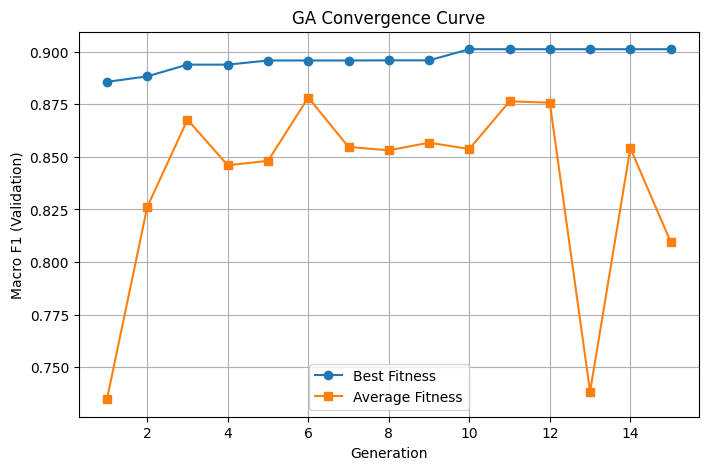

Epoch 10/100 - loss: 0.3503 - val_loss: 0.3541 - val_f1: 0.8502
Epoch 20/100 - loss: 0.2641 - val_loss: 0.3302 - val_f1: 0.8639
Epoch 30/100 - loss: 0.2404 - val_loss: 0.3384 - val_f1: 0.8647
Epoch 40/100 - loss: 0.2270 - val_loss: 0.3135 - val_f1: 0.8679
Early stopping at epoch 45


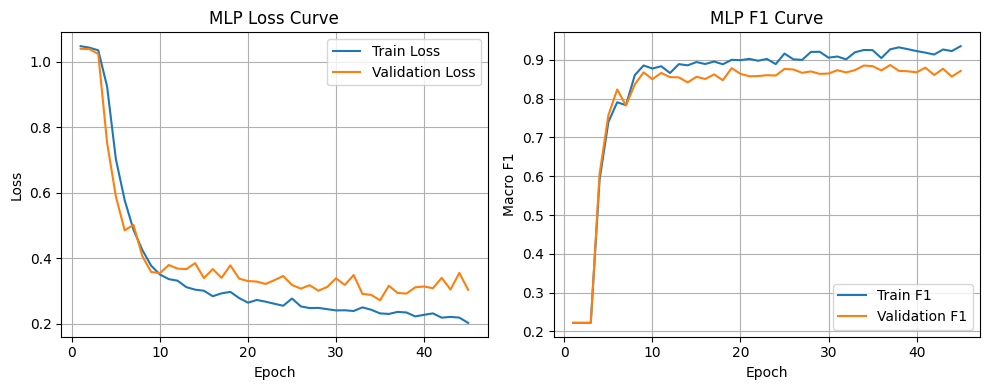

In [5]:
# plot for ga algorithm.....................................................................
generations = [h["generation"] for h in history]
best_fitness = [h["best_fitness"] for h in history]
avg_fitness = [h["avg_fitness"] for h in history]

plt.figure(figsize=(8,5))
plt.plot(generations, best_fitness, marker='o', label="Best Fitness")
plt.plot(generations, avg_fitness, marker='s', label="Average Fitness")

plt.xlabel("Generation")
plt.ylabel("Macro F1 (Validation)")
plt.title("GA Convergence Curve")
plt.legend()
plt.grid(True)

plt.show()

# plot for mlp algorithm for best situation
best_params = decode_chromosome(best_chromosome, X_train.shape[1], len(np.unique(y_train)))

best_model = MLP(
    layer_sizes=best_params["layer_sizes"],
    activation=best_params["activation"],
    learning_rate=best_params["learning_rate"],
    l2_lambda=best_params["l2_lambda"],
    weight_init=best_params["weight_init"]
)

history_best = best_model.train(
    X_train, y_train,
    X_val, y_val,
    epochs=100,
    batch_size=best_params["batch_size"],
    early_stopping_patience=10,
    verbose=True
)

epochs = range(1, len(history_best["train_loss"]) + 1)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(epochs, history_best["train_loss"], label="Train Loss")
plt.plot(epochs, history_best["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Loss Curve")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs, history_best["train_f1"], label="Train F1")
plt.plot(epochs, history_best["val_f1"], label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("MLP F1 Curve")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()




